# Exploracion del corpus de audio

**Modalidad C - Panel de Domotica Controlada por Voz**

Este notebook inspecciona el corpus crudo en `Audios/`, revisa propiedades de las grabaciones, muestra ejemplos del pipeline de preprocesamiento (VAD, fix-length, MFCC) y compara muestras originales contra aumentadas.

Lanzar desde la raiz del proyecto con el venv activado.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
import librosa, librosa.display

from src.config import AUDIO_DIR, CLASSES, SAMPLE_RATE, CLIP_DURATION_S, N_MFCC
from src.audio_utils import load_wav, peak_normalize, trim_by_energy, fix_length, preprocess_clip
from src.features import compute_mfcc, compute_mel_spectrogram, standardize_per_feature
from src.augmentation import time_shift, pitch_shift, add_gaussian_noise, spec_augment
from src.build_dataset import discover_samples

print(f'AUDIO_DIR: {AUDIO_DIR}')
print(f'SR={SAMPLE_RATE} Hz   clip={CLIP_DURATION_S}s   N_MFCC={N_MFCC}')

AUDIO_DIR: C:\Landivar\semestre7\Inteligencia artificial\ProyectoFinal_IA\Audios
SR=16000 Hz   clip=1.5s   N_MFCC=40


## 1. Distribucion del corpus

In [2]:
samples = discover_samples(AUDIO_DIR)
print(f'Total muestras validas: {len(samples)}')

from collections import Counter
counts_label = Counter(s.label for s in samples)
counts_env = Counter(s.env for s in samples)
counts_speaker = Counter(s.speaker for s in samples)

print('\nPor clase:')
for c in CLASSES:
    print(f'  {c:14s} {counts_label.get(c, 0)}')
print('\nPor entorno:')
for k, v in counts_env.items():
    print(f'  {k:14s} {v}')
print('\nPor hablante:')
for k, v in counts_speaker.items():
    print(f'  {k:14s} {v}')

Total muestras validas: 177

Por clase:
  APAGA          23
  CERRADURA      23
  ENCIENDE       22
  LUZ            23
  PANEL          23
  RUIDO          40
  VENTILADOR     23

Por entorno:
  silencio       78
  ruido          71
  ambiente       14
  habla          14

Por hablante:
  dereck         177


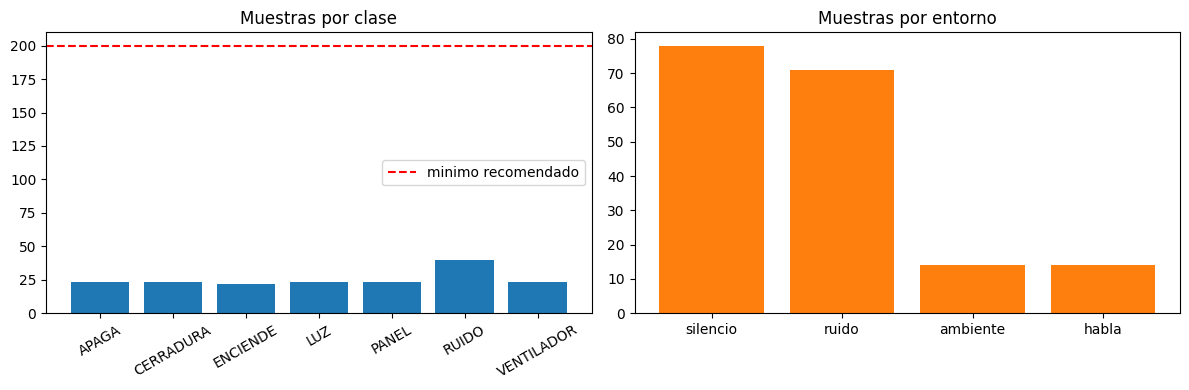

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
labels = list(counts_label.keys())
values = [counts_label[l] for l in labels]
ax[0].bar(labels, values, color='tab:blue')
ax[0].set_title('Muestras por clase')
ax[0].tick_params(axis='x', rotation=30)
ax[0].axhline(200, color='red', linestyle='--', label='minimo recomendado')
ax[0].legend()

env_labels = list(counts_env.keys())
env_values = [counts_env[l] for l in env_labels]
ax[1].bar(env_labels, env_values, color='tab:orange')
ax[1].set_title('Muestras por entorno')
plt.tight_layout(); plt.show()

## 2. Distribucion de duraciones

min=0.395s   mean=0.759s   max=1.091s


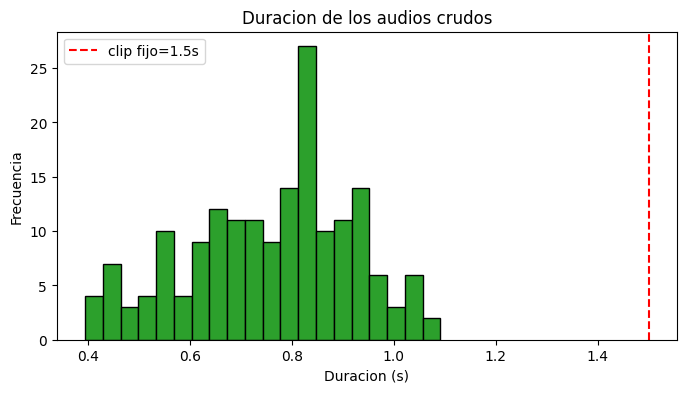

In [4]:
durs = []
for s in samples:
    y = load_wav(s.path)
    durs.append(len(y)/SAMPLE_RATE)
durs = np.array(durs)
print(f'min={durs.min():.3f}s   mean={durs.mean():.3f}s   max={durs.max():.3f}s')
plt.figure(figsize=(8, 4))
plt.hist(durs, bins=20, color='tab:green', edgecolor='black')
plt.axvline(CLIP_DURATION_S, color='red', linestyle='--', label=f'clip fijo={CLIP_DURATION_S}s')
plt.xlabel('Duracion (s)'); plt.ylabel('Frecuencia')
plt.title('Duracion de los audios crudos')
plt.legend(); plt.show()

## 3. Pipeline de preprocesamiento sobre una muestra

Archivo: APAGA_dereck_01_silencio.wav


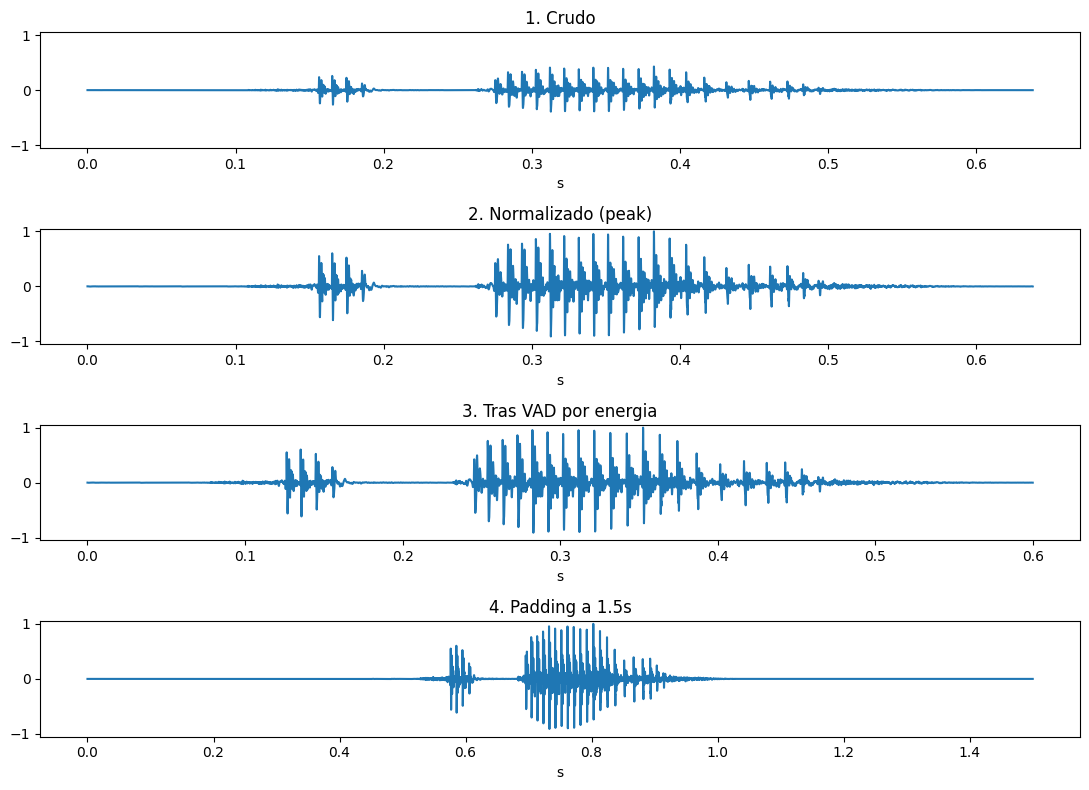

In [5]:
sample = samples[0]
print(f'Archivo: {sample.path.name}')
y_raw = load_wav(sample.path)
y_norm = peak_normalize(y_raw)
y_vad = trim_by_energy(y_norm)
y_fixed = fix_length(peak_normalize(y_vad))

fig, ax = plt.subplots(4, 1, figsize=(11, 8), sharex=False)
ax[0].plot(np.linspace(0, len(y_raw)/SAMPLE_RATE, len(y_raw)), y_raw); ax[0].set_title('1. Crudo')
ax[1].plot(np.linspace(0, len(y_norm)/SAMPLE_RATE, len(y_norm)), y_norm); ax[1].set_title('2. Normalizado (peak)')
ax[2].plot(np.linspace(0, len(y_vad)/SAMPLE_RATE, len(y_vad)), y_vad); ax[2].set_title('3. Tras VAD por energia')
ax[3].plot(np.linspace(0, len(y_fixed)/SAMPLE_RATE, len(y_fixed)), y_fixed); ax[3].set_title(f'4. Padding a {CLIP_DURATION_S}s')
for a in ax: a.set_ylim(-1.05, 1.05); a.set_xlabel('s')
plt.tight_layout(); plt.show()

## 4. MFCC y Mel-spectrogram (un ejemplo por clase)

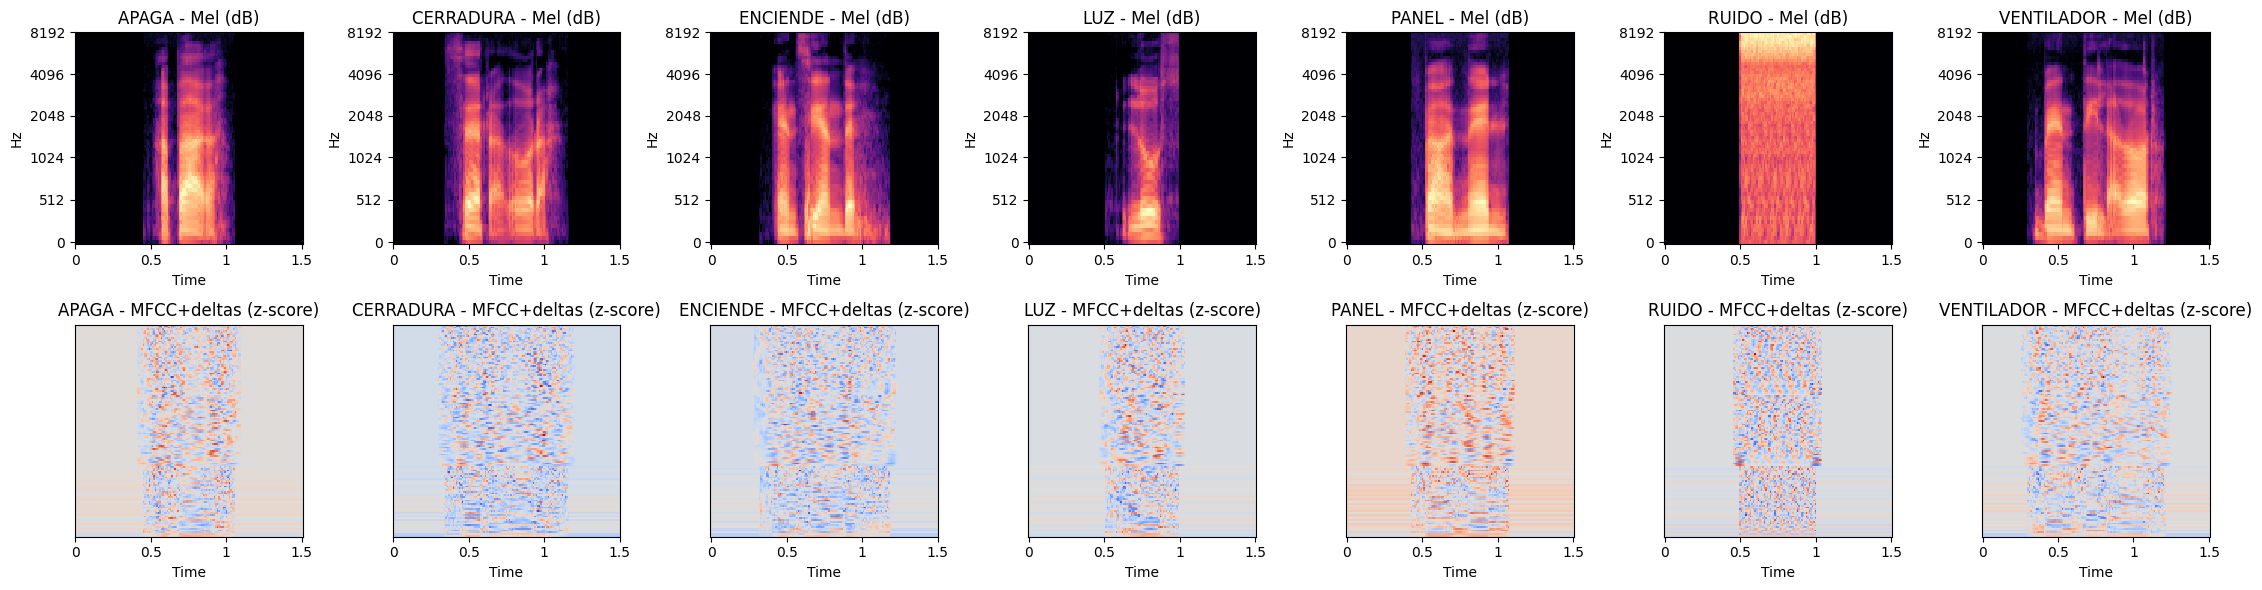

In [6]:
from src.config import HOP_LENGTH
one_per_class = {}
for s in samples:
    one_per_class.setdefault(s.label, s)
labels_seen = sorted(one_per_class.keys())
n = len(labels_seen)
fig, axes = plt.subplots(2, n, figsize=(3.2*n, 6))
if n == 1: axes = np.array([[axes[0]],[axes[1]]])
for i, c in enumerate(labels_seen):
    s = one_per_class[c]
    y = preprocess_clip(s.path)
    mel = compute_mel_spectrogram(y)
    mfcc = standardize_per_feature(compute_mfcc(y))
    librosa.display.specshow(mel, sr=SAMPLE_RATE, hop_length=HOP_LENGTH, x_axis='time', y_axis='mel', ax=axes[0, i])
    axes[0, i].set_title(f'{c} - Mel (dB)')
    librosa.display.specshow(mfcc, sr=SAMPLE_RATE, hop_length=HOP_LENGTH, x_axis='time', ax=axes[1, i])
    axes[1, i].set_title(f'{c} - MFCC+deltas (z-score)')
plt.tight_layout(); plt.show()

## 5. Data augmentation visualizada

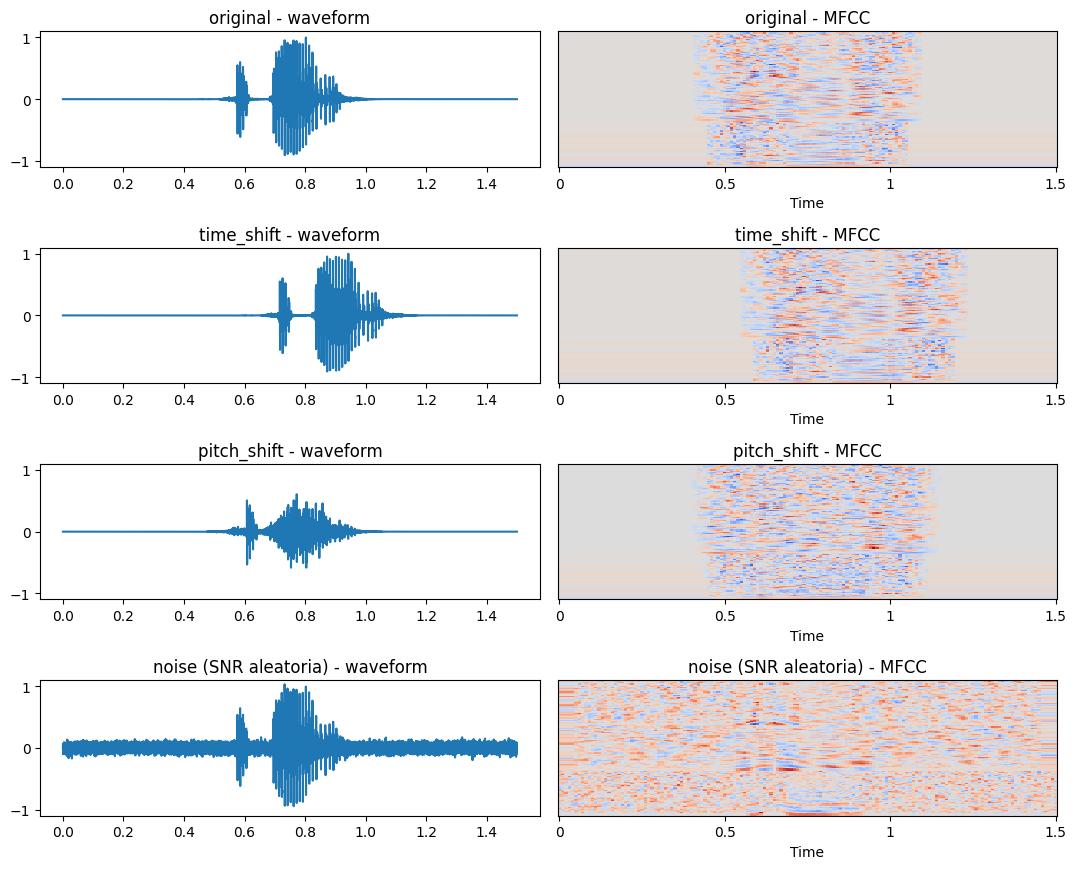

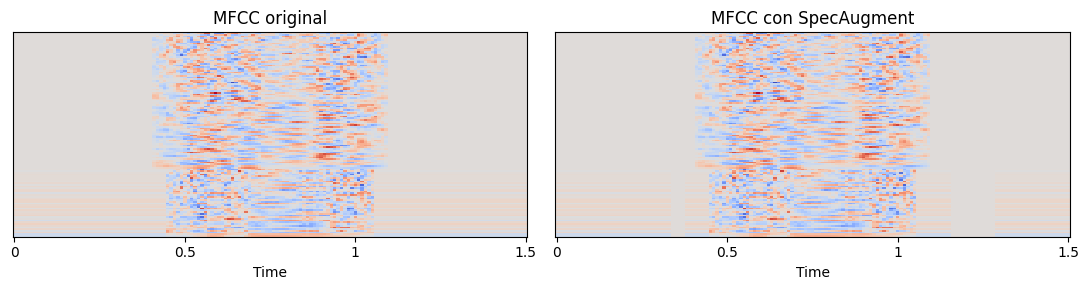

In [7]:
rng = np.random.default_rng(0)
y = preprocess_clip(samples[0].path)
variants = {
    'original': y,
    'time_shift': time_shift(y, rng),
    'pitch_shift': pitch_shift(y, rng),
    'noise (SNR aleatoria)': add_gaussian_noise(y, rng),
}
fig, axes = plt.subplots(len(variants), 2, figsize=(11, 2.2*len(variants)))
for i, (name, v) in enumerate(variants.items()):
    axes[i, 0].plot(np.linspace(0, len(v)/SAMPLE_RATE, len(v)), v)
    axes[i, 0].set_title(f'{name} - waveform'); axes[i, 0].set_ylim(-1.1, 1.1)
    mfcc = standardize_per_feature(compute_mfcc(v))
    librosa.display.specshow(mfcc, sr=SAMPLE_RATE, hop_length=HOP_LENGTH, x_axis='time', ax=axes[i, 1])
    axes[i, 1].set_title(f'{name} - MFCC')
plt.tight_layout(); plt.show()

mfcc_clean = standardize_per_feature(compute_mfcc(y))
mfcc_specaug = spec_augment(mfcc_clean, rng)
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
librosa.display.specshow(mfcc_clean, sr=SAMPLE_RATE, hop_length=HOP_LENGTH, x_axis='time', ax=axes[0]); axes[0].set_title('MFCC original')
librosa.display.specshow(mfcc_specaug, sr=SAMPLE_RATE, hop_length=HOP_LENGTH, x_axis='time', ax=axes[1]); axes[1].set_title('MFCC con SpecAugment')
plt.tight_layout(); plt.show()

## 6. Verificacion del dataset.npz (correr despues de `python -m src.build_dataset`)

In [8]:
from src.config import PROCESSED_DIR
npz_path = PROCESSED_DIR / 'dataset.npz'
if npz_path.exists():
    d = np.load(npz_path)
    print('keys:', list(d.keys()))
    for k in ['X_train', 'X_val', 'X_test']:
        print(f'{k}: shape={d[k].shape}  dtype={d[k].dtype}')
    for k in ['y_train', 'y_val', 'y_test']:
        u, c = np.unique(d[k], return_counts=True)
        print(f'{k}: {dict(zip(u.tolist(), c.tolist()))}')
else:
    print(f'Aun no existe {npz_path}. Corre:  python -m src.build_dataset')

keys: ['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test', 'classes', 'sample_rate', 'clip_samples']
X_train: shape=(618, 120, 151)  dtype=float32
X_val: shape=(23, 120, 151)  dtype=float32
X_test: shape=(23, 120, 151)  dtype=float32
y_train: {0: 96, 1: 96, 2: 96, 3: 90, 4: 96, 5: 48, 6: 96}
y_val: {0: 3, 1: 4, 2: 3, 3: 4, 4: 3, 5: 2, 6: 4}
y_test: {0: 4, 1: 3, 2: 3, 3: 4, 4: 4, 5: 2, 6: 3}
